B.1 Dataset dan Setup

1. Import Library

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


2. Menentukan Device (CPU/GPU)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cuda


3. Preprocessing Dataset

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

print("Transformasi berhasil dibuat!")


Transformasi berhasil dibuat!


4. Load Dataset CIFAR-10

In [5]:
train_full = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Dataset berhasil dimuat!")
print("Data training :", len(train_full))


100%|██████████| 170M/170M [27:02<00:00, 105kB/s]


Dataset berhasil dimuat!
Data training : 50000


5. Membagi Data Training dan Validation

In [6]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size]
)

print("Jumlah data training   :", len(train_dataset))
print("Jumlah data validation :", len(val_dataset))
print("Jumlah data testing    :", len(test_dataset))


Jumlah data training   : 40000
Jumlah data validation : 10000
Jumlah data testing    : 10000


6. Membuat DataLoader

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

In [8]:
print("DataLoader berhasil di-import!")

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoader berhasil dibuat!")


DataLoader berhasil di-import!
DataLoader berhasil dibuat!


7. Mengecek Bentuk Data

In [9]:
images, labels = next(iter(train_loader))

print("Ukuran gambar :", images.shape)


Ukuran gambar : torch.Size([128, 3, 32, 32])


8. Visualisasi Contoh Dataset

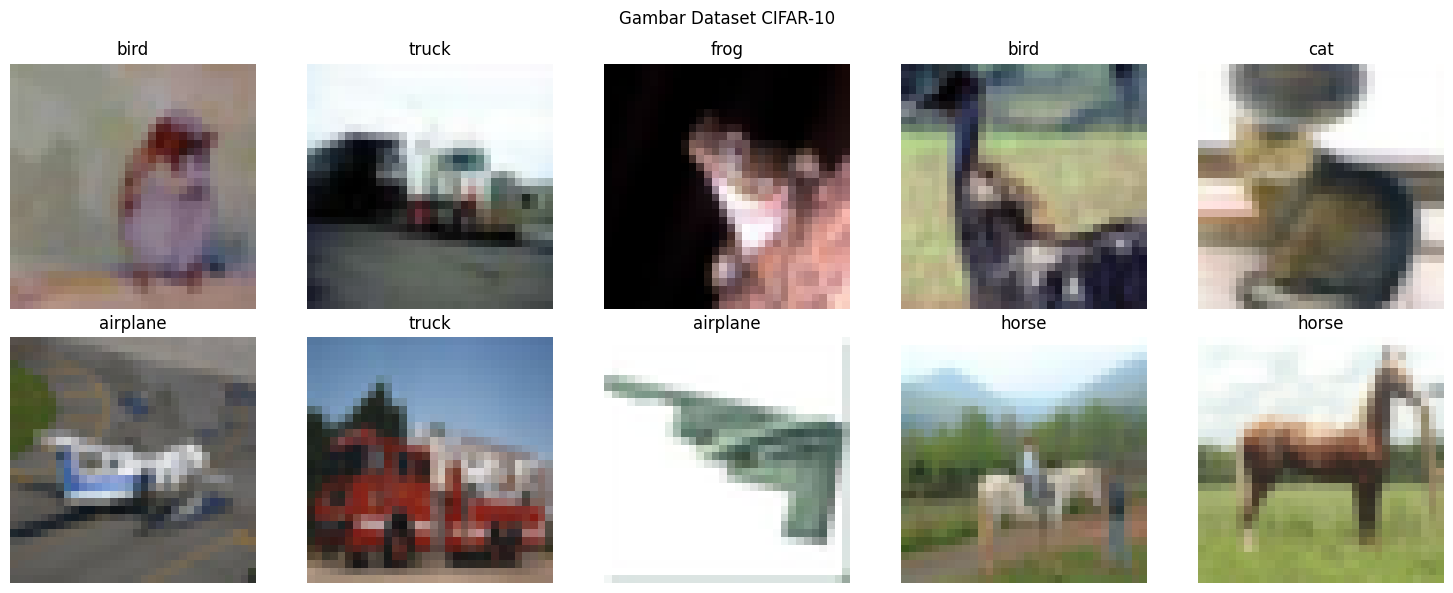

In [35]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(15, 6))

for i in range(10):
    image = images[i] / 2 + 0.5
    image = image.permute(1, 2, 0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(classes[labels[i].item()])
    plt.axis("off")

plt.suptitle("Gambar Dataset CIFAR-10")
plt.tight_layout()
plt.show()

B.2 — Implementasi Model

j) Model A — CNN Sederhana

In [11]:
class CNN_Sederhana(nn.Module):
    def __init__(self):
        super(CNN_Sederhana, self).__init__()

        # Blok 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # Blok 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Blok 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        # Fully Connected
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        x = x.view(x.size(0), -1)

        x = self.relu1(self.fc1(x))
        x = self.fc2(x)

        return x


model_A = CNN_Sederhana().to(device)

print(model_A)


CNN_Sederhana(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


Jumlah Parameter Model A

In [12]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

total_params_A = count_parameters(model_A)

print("Jumlah parameter Model A:", total_params_A)


Jumlah parameter Model A: 620362


Loss Function, Optimizer, dan Epoch Model A

In [13]:
import torch.optim as optim

print("Optimizer berhasil di-import!")

criterion = nn.CrossEntropyLoss()

optimizer_A = optim.Adam(
    model_A.parameters(),
    lr=0.001
)

num_epochs = 10

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print("Learning rate : 0.001")
print("Epoch         :", num_epochs)


Optimizer berhasil di-import!
Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.001
Epoch         : 10


Training Model A

In [14]:
import time

print("time berhasil di-import!")

train_losses_A = []
val_losses_A = []

train_accs_A = []
val_accs_A = []

start_time_A = time.time()

for epoch in range(num_epochs):

    model_A.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_A.zero_grad()

        outputs = model_A(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_A.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total


    model_A.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_A(images)

            loss = criterion(outputs, labels)

            val_loss_total += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss_total / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses_A.append(train_loss)
    val_losses_A.append(val_loss)

    train_accs_A.append(train_acc)
    val_accs_A.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

end_time_A = time.time()

training_time_A = end_time_A - start_time_A

print("\nTraining selesai!")
print(f"Waktu training Model A: {training_time_A:.2f} detik")


time berhasil di-import!
Epoch [1/10] Train Loss: 1.5329 Train Acc: 44.25% Val Loss: 1.2875 Val Acc: 53.31%
Epoch [2/10] Train Loss: 1.1154 Train Acc: 60.45% Val Loss: 1.0282 Val Acc: 63.46%
Epoch [3/10] Train Loss: 0.9168 Train Acc: 67.78% Val Loss: 0.9394 Val Acc: 66.53%
Epoch [4/10] Train Loss: 0.7836 Train Acc: 72.72% Val Loss: 0.8252 Val Acc: 71.01%
Epoch [5/10] Train Loss: 0.6720 Train Acc: 76.49% Val Loss: 0.7930 Val Acc: 72.52%
Epoch [6/10] Train Loss: 0.5704 Train Acc: 79.98% Val Loss: 0.7735 Val Acc: 74.15%
Epoch [7/10] Train Loss: 0.4852 Train Acc: 83.02% Val Loss: 0.7814 Val Acc: 73.20%
Epoch [8/10] Train Loss: 0.4074 Train Acc: 85.81% Val Loss: 0.7990 Val Acc: 74.49%
Epoch [9/10] Train Loss: 0.3203 Train Acc: 88.86% Val Loss: 0.8748 Val Acc: 73.95%
Epoch [10/10] Train Loss: 0.2577 Train Acc: 91.01% Val Loss: 0.9821 Val Acc: 73.12%

Training selesai!
Waktu training Model A: 144.47 detik


k) Model B — CNN dengan Residual Connection

Residual Block

In [15]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, padding=1
        )
        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, padding=1
        )

        # Shortcut
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(
                in_channels, out_channels,
                kernel_size=1
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)

        # Residual connection
        out = out + identity

        out = self.relu(out)

        return out


Arsitektur Model B

In [16]:
class ResidualCNN(nn.Module):
    def __init__(self):
        super(ResidualCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            3, 32,
            kernel_size=3,
            padding=1
        )
        self.relu = nn.ReLU()

        # Residual Block 1
        self.res1 = ResidualBlock(32, 32)

        # Pooling
        self.pool1 = nn.MaxPool2d(2, 2)

        # Residual Block 2
        self.res2 = ResidualBlock(32, 64)

        # Pooling
        self.pool2 = nn.MaxPool2d(2, 2)

        # Residual Block 3
        self.res3 = ResidualBlock(64, 128)

        # Pooling
        self.pool3 = nn.MaxPool2d(2, 2)

        # Fully Connected
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        x = self.relu(self.conv1(x))

        # Residual Block 1
        x = self.res1(x)
        x = self.pool1(x)

        # Residual Block 2
        x = self.res2(x)
        x = self.pool2(x)

        # Residual Block 3
        x = self.res3(x)
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


Membuat Model B

In [17]:
model_B = ResidualCNN().to(device)

print(model_B)


ResidualCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (res1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (shortcut): Identity()
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (res2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (shortcut): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (res3): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (shortcu

Jumlah Parameter Model B

In [18]:
total_params_B = count_parameters(model_B)

print("Jumlah parameter Model B:", total_params_B)


Jumlah parameter Model B: 833802


Loss Function, Optimizer, dan Epoch Model B

In [19]:
criterion_B = nn.CrossEntropyLoss()

optimizer_B = optim.Adam(
    model_B.parameters(),
    lr=0.001
)

num_epochs_B = 10

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print("Learning rate : 0.001")
print("Epoch         :", num_epochs_B)


Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.001
Epoch         : 10


Training Model B

In [20]:
train_losses_B = []
val_losses_B = []

train_accs_B = []
val_accs_B = []

start_time_B = time.time()

for epoch in range(num_epochs_B):

    model_B.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_B.zero_grad()

        outputs = model_B(images)

        loss = criterion_B(outputs, labels)

        loss.backward()

        optimizer_B.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total


    model_B.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_B(images)

            loss = criterion_B(outputs, labels)

            val_loss_total += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss_total / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses_B.append(train_loss)
    val_losses_B.append(val_loss)

    train_accs_B.append(train_acc)
    val_accs_B.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs_B}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

end_time_B = time.time()

training_time_B = end_time_B - start_time_B

print("\nTraining Model B selesai!")
print(f"Waktu training Model B: {training_time_B:.2f} detik")


Epoch [1/10] Train Loss: 1.5087 Train Acc: 44.80% Val Loss: 1.2332 Val Acc: 54.90%
Epoch [2/10] Train Loss: 1.0540 Train Acc: 62.43% Val Loss: 0.9395 Val Acc: 67.04%
Epoch [3/10] Train Loss: 0.8287 Train Acc: 70.79% Val Loss: 0.8314 Val Acc: 71.14%
Epoch [4/10] Train Loss: 0.6691 Train Acc: 76.69% Val Loss: 0.7274 Val Acc: 74.71%
Epoch [5/10] Train Loss: 0.5512 Train Acc: 80.50% Val Loss: 0.7406 Val Acc: 74.88%
Epoch [6/10] Train Loss: 0.4439 Train Acc: 84.35% Val Loss: 0.6778 Val Acc: 77.21%
Epoch [7/10] Train Loss: 0.3416 Train Acc: 87.98% Val Loss: 0.7103 Val Acc: 77.04%
Epoch [8/10] Train Loss: 0.2663 Train Acc: 90.64% Val Loss: 0.7452 Val Acc: 77.93%
Epoch [9/10] Train Loss: 0.1967 Train Acc: 93.00% Val Loss: 0.8702 Val Acc: 76.81%
Epoch [10/10] Train Loss: 0.1490 Train Acc: 94.58% Val Loss: 0.9172 Val Acc: 77.29%

Training Model B selesai!
Waktu training Model B: 195.20 detik


B.3 — Eksperimen dan Evaluasi



1. Kurva Training Loss dan Validation Loss

Model A

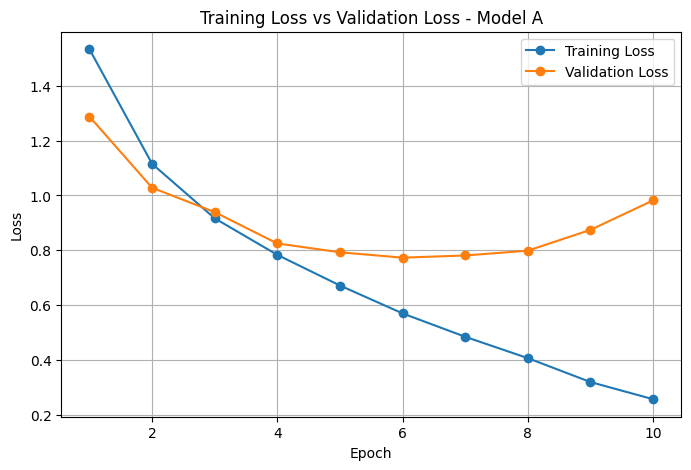

In [21]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses_A,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses_A,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss - Model A")
plt.legend()
plt.grid()
plt.show()


Model B

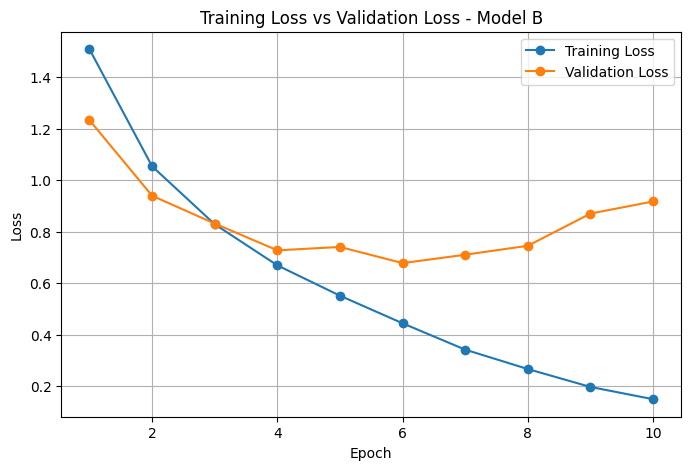

In [22]:
"""- Grafik Loss Model B"""

epochs_range_B = range(1, num_epochs_B + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_B,
    train_losses_B,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range_B,
    val_losses_B,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss - Model B")
plt.legend()
plt.grid()
plt.show()


2. Kurva Training Accuracy dan Validation Accuracy

Model A

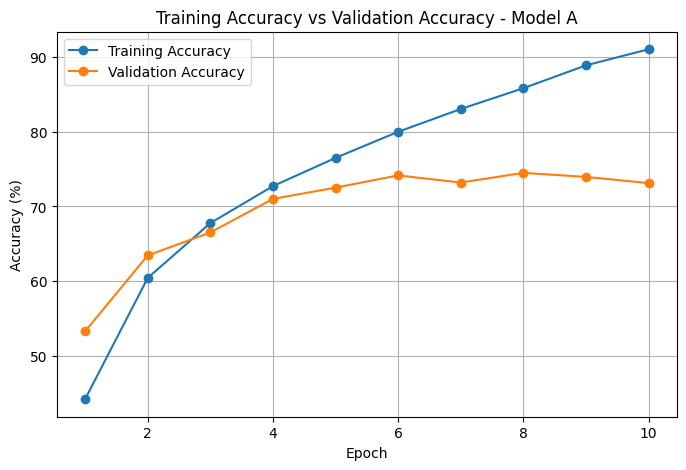

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accs_A,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accs_A,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Validation Accuracy - Model A")
plt.legend()
plt.grid()
plt.show()


Model B

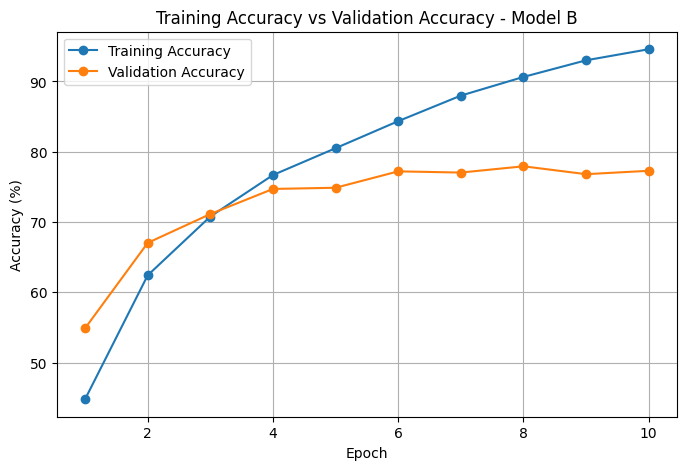

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_B,
    train_accs_B,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range_B,
    val_accs_B,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Validation Accuracy - Model B")
plt.legend()
plt.grid()
plt.show()


3. Akurasi Akhir pada Test Set

Model A

In [25]:
model_A.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_A(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy_A = 100 * correct / total

print(f"Test Accuracy Model A: {test_accuracy_A:.2f}%")


Test Accuracy Model A: 73.22%


Model B

In [26]:
model_B.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_B(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy_B = 100 * correct / total

print(f"Test Accuracy Model B: {test_accuracy_B:.2f}%")


Test Accuracy Model B: 77.04%


4. Jumlah Total Parameter Tiap Model

In [27]:
print("Jumlah parameter Model A:", total_params_A)
print("Jumlah parameter Model B:", total_params_B)


Jumlah parameter Model A: 620362
Jumlah parameter Model B: 833802


5. Waktu Training Total

In [28]:
print(f"Waktu training Model A: {training_time_A:.2f} detik")
print(f"Waktu training Model B: {training_time_B:.2f} detik")


Waktu training Model A: 144.47 detik
Waktu training Model B: 195.20 detik


6. Confusion Matrix pada Test Set

Model A

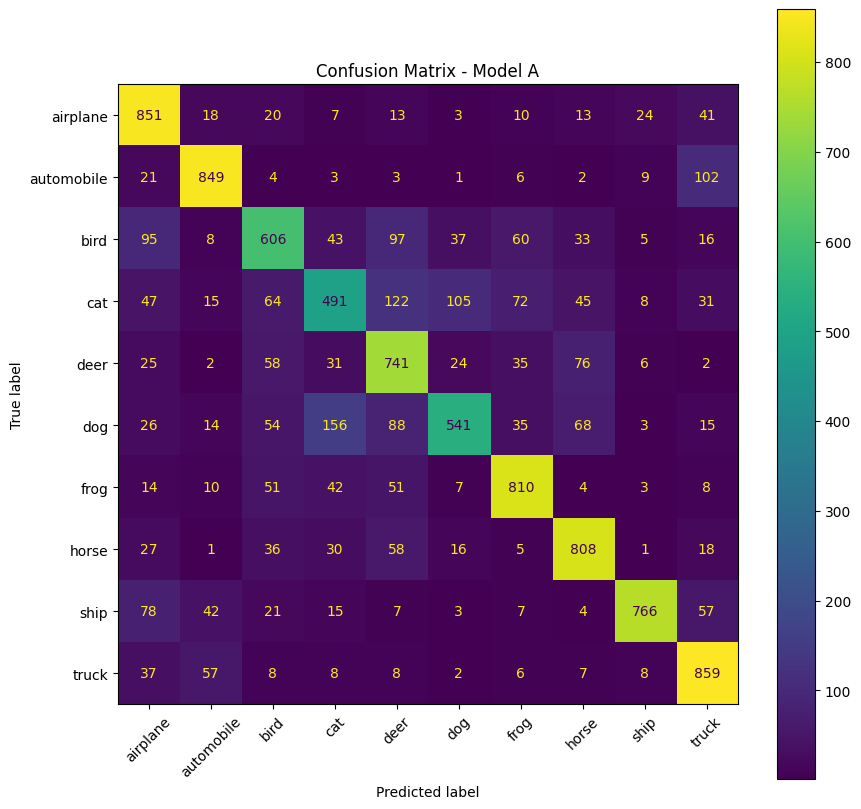

In [29]:
model_A.eval()

all_labels_A = []
all_predictions_A = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_A(images)
        _, predicted = torch.max(outputs, 1)

        all_labels_A.extend(labels.cpu().numpy())
        all_predictions_A.extend(predicted.cpu().numpy())

cm_A = confusion_matrix(
    all_labels_A,
    all_predictions_A
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_A,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Model A")
plt.show()


Model B

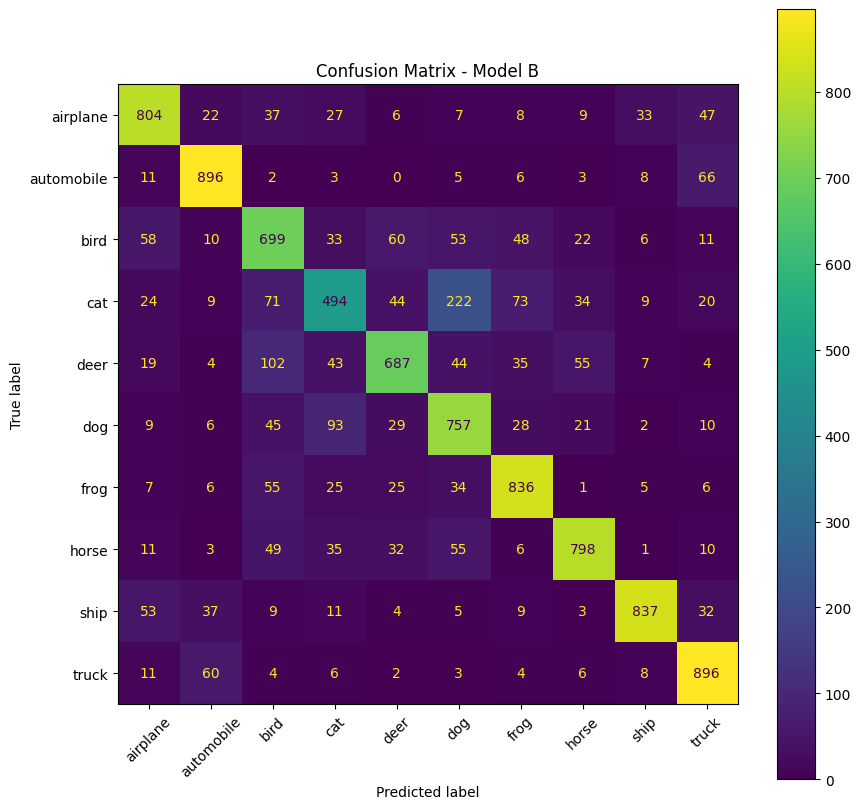

In [30]:
model_B.eval()

all_labels_B = []
all_predictions_B = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_B(images)

        _, predicted = torch.max(outputs, 1)

        all_labels_B.extend(labels.cpu().numpy())
        all_predictions_B.extend(predicted.cpu().numpy())


cm_B = confusion_matrix(
    all_labels_B,
    all_predictions_B
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_B,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Model B")
plt.show()


Tabel Perbandingan Model A dan Model B

In [31]:
import pandas as pd

hasil_perbandingan = pd.DataFrame({
    "Model": ["Model A", "Model B"],
    "Test Accuracy (%)": [
        test_accuracy_A,
        test_accuracy_B
    ],
    "Jumlah Parameter": [
        total_params_A,
        total_params_B
    ],
    "Waktu Training (detik)": [
        training_time_A,
        training_time_B
    ]
})

hasil_perbandingan


,Model,Test Accuracy (%),Jumlah Parameter,Waktu Training (detik)
0,Model A,73.22,620362,144.467680
1,Model B,77.04,833802,195.202443


In [32]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU TIDAK TERDETEKSI")

PyTorch version: 2.11.0+cu128
CUDA tersedia: True
GPU: Tesla T4


In [33]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA tersedia: True
GPU: Tesla T4
